# Phase D — Değerlendirme (5 model, OOF)

Phase C'nin OOF (out-of-fold) çıktılarını okur ve PDF isterlerinin hepsini üretir:
**Accuracy · Precision · Recall(Sensitivity) · Specificity · F-Score · AUC** (per-sınıf + makro/mikro), **confusion matrix**, **ROC eğrileri**, **fold loss eğrileri**, **train/inference time**, 5 model karşılaştırması + v1 baseline, kritik kontroller, örnek tahminler.

Girdi: `DATA_ROOT/oof/<model>_fold<f>.npz` (+ `.json`). **Colab/GPU gerekmez.**

## 0) Kurulum

In [1]:
import os, glob, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# --- Yerel ---
DATA_ROOT = Path('../')
# --- Colab ---
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = Path('/content/drive/MyDrive/film-genre-project-data')

OOF_DIR = DATA_ROOT / 'oof'
FIG_DIR = DATA_ROOT / 'figures'; FIG_DIR.mkdir(exist_ok=True)
with open(DATA_ROOT / 'mlb.pkl', 'rb') as f:
    mlb = pickle.load(f)
CLASSES = list(mlb.classes_); C = len(CLASSES)

# v1 baseline (rapor karsilastirmasi icin)
V1 = {'Scratch CNN v1': 0.3327, 'Frozen baseline v1': 0.3832}
print('Siniflar:', C, '| OOF dizini:', OOF_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Siniflar: 15 | OOF dizini: /content/drive/MyDrive/film-genre-project-data/oof


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MultiLabelBinarizer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 1) OOF yükle (her model = 5 fold birleşimi)

In [2]:
files = sorted(glob.glob(str(OOF_DIR / '*_fold*.npz')))
models = sorted(set(os.path.basename(f).rsplit('_fold', 1)[0] for f in files))
print('Bulunan modeller:', models)

data = {}
for m in models:
    P, Y, ids, hist, tt, it = [], [], [], [], [], []
    for fold in range(5):
        npz = OOF_DIR / ('%s_fold%d.npz' % (m, fold))
        js  = OOF_DIR / ('%s_fold%d.json' % (m, fold))
        if not npz.exists():
            continue
        d = np.load(npz, allow_pickle=True)
        P.append(d['probs']); Y.append(d['targets']); ids.append(d['ids'])
        if js.exists():
            j = json.load(open(js))
            hist.append(j['hist']); tt.append(j['train_time_s']); it.append(j['infer_ms_per_img'])
    data[m] = {'probs': np.concatenate(P), 'targets': np.concatenate(Y),
               'ids': np.concatenate(ids), 'hist': hist, 'train_time': tt, 'infer_ms': it}
    print('  %-6s OOF probs=%s  (fold=%d)' % (m, data[m]['probs'].shape, len(P)))

Bulunan modeller: ['beit', 'cvt', 'deit', 'swin', 'vit']
  beit   OOF probs=(23640, 15)  (fold=5)
  cvt    OOF probs=(23640, 15)  (fold=5)
  deit   OOF probs=(23640, 15)  (fold=5)
  swin   OOF probs=(23640, 15)  (fold=5)
  vit    OOF probs=(23640, 15)  (fold=5)


## 2) Threshold optimizasyonu + metrik fonksiyonları

In [3]:
from sklearn.metrics import f1_score, roc_auc_score, multilabel_confusion_matrix

def per_class_thresholds(probs, targets, grid=np.arange(0.30, 0.71, 0.05)):
    thr = np.full(probs.shape[1], 0.5)
    for c in range(probs.shape[1]):
        best = -1.0
        for t in grid:
            f = f1_score(targets[:, c], (probs[:, c] >= t).astype(int), zero_division=0)
            if f > best:
                best, thr[c] = f, t
    return thr

def evaluate(probs, targets, thr):
    pred = (probs >= thr).astype(int)
    mcm = multilabel_confusion_matrix(targets, pred)   # (C,2,2): [[TN,FP],[FN,TP]]
    rows = []
    for c in range(probs.shape[1]):
        tn, fp, fn, tp = mcm[c].ravel()
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        acc  = (tp + tn) / (tp + tn + fp + fn)
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        try:
            auc = roc_auc_score(targets[:, c], probs[:, c])
        except ValueError:
            auc = float('nan')
        rows.append([prec, rec, spec, acc, f1, auc])
    df = pd.DataFrame(rows, index=CLASSES,
                      columns=['precision', 'recall_sens', 'specificity', 'accuracy', 'f1', 'auc'])
    macro = df.mean()
    micro_f1  = f1_score(targets, pred, average='micro', zero_division=0)
    micro_auc = roc_auc_score(targets, probs, average='micro')
    return df, macro, micro_f1, micro_auc, pred

## 3) Model başına metrik + karşılaştırma tablosu

In [4]:
results = {}
for m in models:
    P, Y = data[m]['probs'], data[m]['targets']
    thr = per_class_thresholds(P, Y)
    df, macro, micro_f1, micro_auc, pred = evaluate(P, Y, thr)
    results[m] = {'per_class': df, 'macro': macro, 'micro_f1': micro_f1,
                  'micro_auc': micro_auc, 'thr': thr, 'pred': pred}

comp = pd.DataFrame({
    'macro_F1':  {m: results[m]['macro']['f1'] for m in models},
    'micro_F1':  {m: results[m]['micro_f1'] for m in models},
    'macro_AUC': {m: results[m]['macro']['auc'] for m in models},
    'macro_prec':{m: results[m]['macro']['precision'] for m in models},
    'macro_rec': {m: results[m]['macro']['recall_sens'] for m in models},
})
for name, f1 in V1.items():
    comp.loc[name] = [f1, np.nan, np.nan, np.nan, np.nan]
comp = comp.sort_values('macro_F1', ascending=False)
print(comp.round(4))
best_model = comp.drop(index=list(V1)).index[0]
print('\nEn iyi model:', best_model)

                    macro_F1  micro_F1  macro_AUC  macro_prec  macro_rec
swin                  0.5620    0.5660     0.8624      0.5408     0.5867
beit                  0.5343    0.5388     0.8436      0.5172     0.5551
vit                   0.5272    0.5352     0.8408      0.5119     0.5453
deit                  0.5242    0.5296     0.8364      0.5191     0.5318
cvt                   0.5009    0.5094     0.8230      0.4742     0.5356
Frozen baseline v1    0.3832       NaN        NaN         NaN        NaN
Scratch CNN v1        0.3327       NaN        NaN         NaN        NaN

En iyi model: swin


## 3b) Per-sınıf F1 — 5 model karşılaştırma (bar)

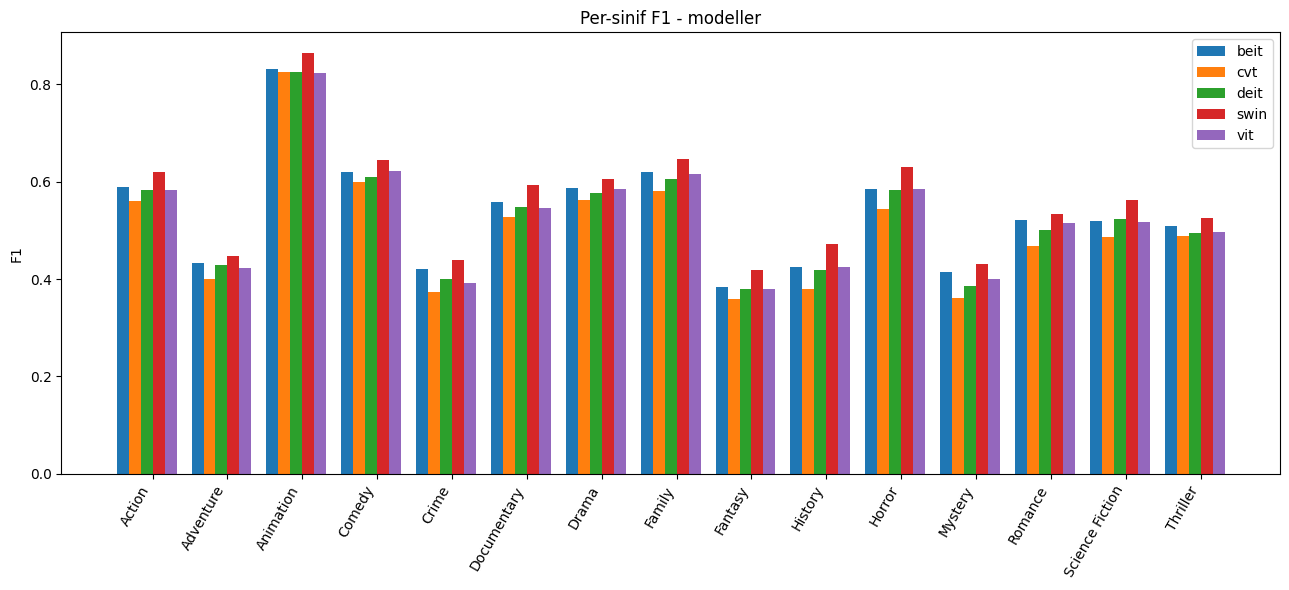

In [5]:
x = np.arange(C); w = 0.8 / max(len(models), 1)
plt.figure(figsize=(13, 6))
for i, m in enumerate(models):
    plt.bar(x + i * w, results[m]['per_class']['f1'].values, width=w, label=m)
plt.xticks(x + 0.4, CLASSES, rotation=60, ha='right')
plt.ylabel('F1'); plt.title('Per-sinif F1 - modeller'); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / 'per_class_f1_models.png', dpi=120); plt.show()

## 4) Her model — per-sınıf metrikler (+ CSV kaydı)

In [ ]:
for m in models:
    print('=== %s — per-sinif metrikler ===' % m)
    print(results[m]['per_class'].round(3))
    mac = results[m]['macro']
    print('Makro F1=%.4f prec=%.4f rec=%.4f spec=%.4f AUC=%.4f | Mikro F1=%.4f AUC=%.4f'
          % (mac['f1'], mac['precision'], mac['recall_sens'], mac['specificity'], mac['auc'],
             results[m]['micro_f1'], results[m]['micro_auc']))
    results[m]['per_class'].round(4).to_csv(FIG_DIR / ('metrics_%s.csv' % m))
    print()

## 5) Confusion matrix (per-sınıf 2×2) — HER model

In [ ]:
for m in models:
    Yv, predv = data[m]['targets'], results[m]['pred']
    mcm = multilabel_confusion_matrix(Yv, predv)
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    for c, ax in enumerate(axes.ravel()):
        if c >= C:
            ax.axis('off'); continue
        cm = mcm[c]; ax.imshow(cm, cmap='Blues')
        for (ii, jj), v in np.ndenumerate(cm):
            ax.text(jj, ii, str(v), ha='center', va='center')
        ax.set_title(CLASSES[c], fontsize=9)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['neg', 'pos'], fontsize=7)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['neg', 'pos'], fontsize=7)
    fig.suptitle('Confusion matrix (per-sinif) — %s' % m)
    plt.tight_layout(); plt.savefig(FIG_DIR / ('confusion_%s.png' % m), dpi=120); plt.show()

## 6) ROC eğrileri (one-vs-rest) — HER model

In [ ]:
from sklearn.metrics import roc_curve, auc as auc_fn
for m in models:
    Pv, Yv = data[m]['probs'], data[m]['targets']
    plt.figure(figsize=(9, 7))
    for c in range(C):
        fpr, tpr, _ = roc_curve(Yv[:, c], Pv[:, c])
        plt.plot(fpr, tpr, lw=1, label='%s (%.2f)' % (CLASSES[c], auc_fn(fpr, tpr)))
    plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title('ROC (one-vs-rest) — %s | makro AUC=%.3f' % (m, results[m]['macro']['auc']))
    plt.legend(fontsize=7, ncol=2); plt.tight_layout()
    plt.savefig(FIG_DIR / ('roc_%s.png' % m), dpi=120); plt.show()

## 7) Fold loss eğrileri (her model, train + val aynı grafikte)

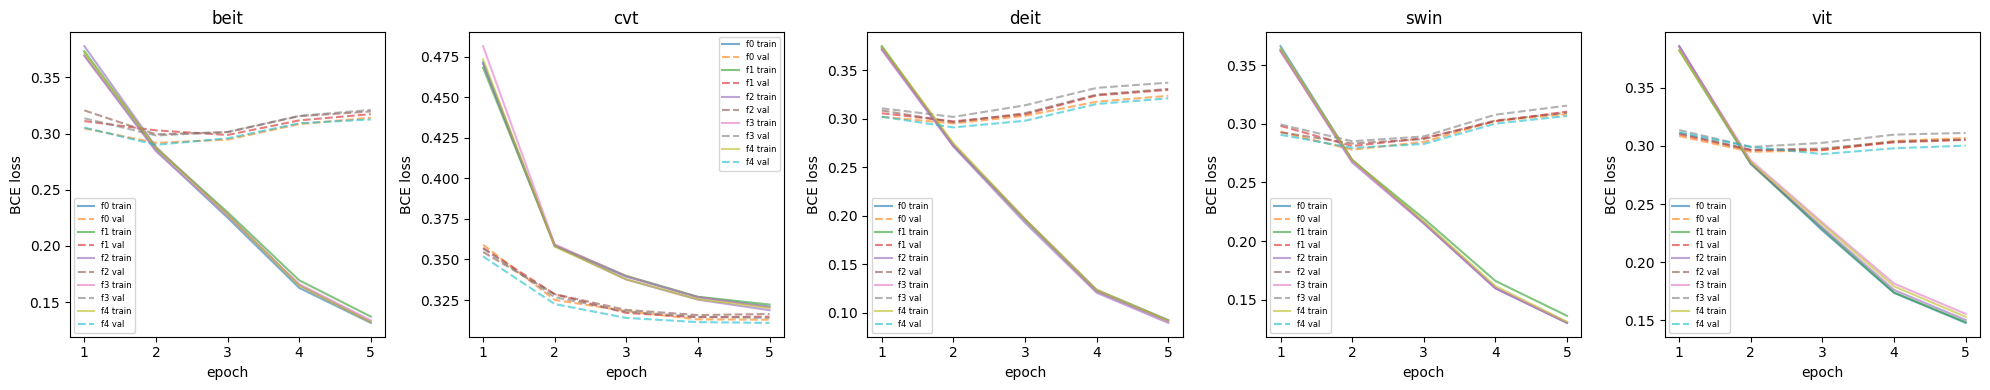

In [9]:
fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 4), squeeze=False)
for ax, m in zip(axes.ravel(), models):
    for fold, h in enumerate(data[m]['hist']):
        ep = range(1, len(h['train_loss']) + 1)
        ax.plot(ep, h['train_loss'], '-',  alpha=0.6, label='f%d train' % fold)
        ax.plot(ep, h['val_loss'],   '--', alpha=0.6, label='f%d val' % fold)
    ax.set_title(m); ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss')
    ax.legend(fontsize=6)
plt.tight_layout(); plt.savefig(FIG_DIR / 'loss_curves.png', dpi=120); plt.show()

## 8) Eğitim / çıkarım süreleri

In [10]:
tim = pd.DataFrame({
    'avg_train_time_s': {m: np.mean(data[m]['train_time']) if data[m]['train_time'] else np.nan for m in models},
    'avg_train_time_dk': {m: np.mean(data[m]['train_time'])/60 if data[m]['train_time'] else np.nan for m in models},
    'infer_ms_per_img': {m: np.mean(data[m]['infer_ms']) if data[m]['infer_ms'] else np.nan for m in models},
}).round(2)
print(tim)

      avg_train_time_s  avg_train_time_dk  infer_ms_per_img
beit            249.32               4.16              1.60
cvt             283.67               4.73              1.58
deit            237.46               3.96              1.58
swin            350.13               5.84              1.63
vit             236.58               3.94              1.58


## 9) Kritik kontroller (over-prediction & frekans biası)

In [11]:
print('Ortalama tahmin edilen tur/film (hedef ~1.5-2.5):')
for m in models:
    avg = results[m]['pred'].sum(axis=1).mean()
    print('  %-6s %.2f' % (m, avg))
print()
print('Frekans biasi kontrolu (%s) — baskin vs az turler F1:' % best_model)
pc = results[best_model]['per_class']['f1']
for g in ['Drama', 'Comedy', 'History', 'Documentary', 'Animation']:
    print('  %-16s %.3f' % (g, pc[g]))

Ortalama tahmin edilen tur/film (hedef ~1.5-2.5):
  beit   2.39
  cvt    2.52
  deit   2.29
  swin   2.41
  vit    2.36

Frekans biasi kontrolu (swin) — baskin vs az turler F1:
  Drama            0.606
  Comedy           0.644
  History          0.471
  Documentary      0.593
  Animation        0.863


## 10) Örnek tahminler (12 afiş)

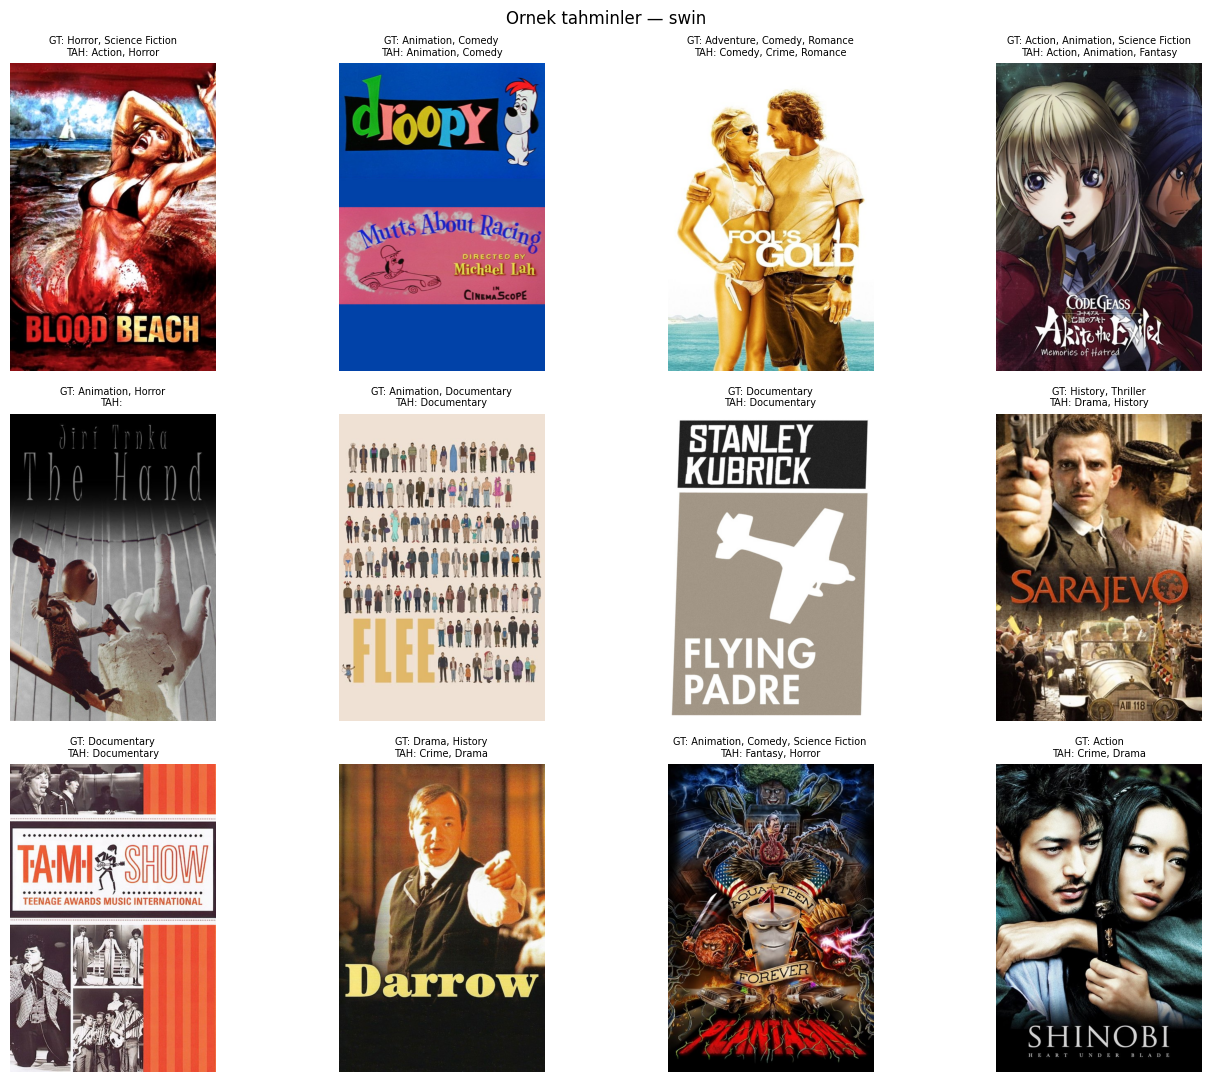

In [12]:
from PIL import Image
POSTERS = DATA_ROOT / 'posters'
ids = data[best_model]['ids']; P = data[best_model]['probs']; Y = data[best_model]['targets']
thr = results[best_model]['thr']
rng = np.random.default_rng(42); sel = rng.choice(len(ids), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, idx in zip(axes.ravel(), sel):
    try:
        ax.imshow(Image.open(POSTERS / (str(ids[idx]) + '.jpg')).convert('RGB'))
    except Exception:
        pass
    ax.axis('off')
    pr = [CLASSES[c] for c in range(C) if P[idx, c] >= thr[c]]
    gt = [CLASSES[c] for c in range(C) if Y[idx, c] == 1]
    ax.set_title('GT: %s\nTAH: %s' % (', '.join(gt), ', '.join(pr)), fontsize=7)
fig.suptitle('Ornek tahminler — %s' % best_model)
plt.tight_layout(); plt.savefig(FIG_DIR / ('samples_%s.png' % best_model), dpi=110); plt.show()